# Análise de Sentimentos

A análise de sentimentos é uma técnica de processamento de linguagem natural que consiste em classificar a opinião expressa em um texto como positiva, negativa ou neutra.

Esse tipo de técnica demonstra vários passos comuns no processamento de linguagem natural, como a tokenização, limpeza de dados e vetorização antes de entrarmos na etapa de classificação.

Neste notebook utilizaremos dois datasets em português brasileiro para treinar e avaliar nosso modelo de análise de sentimentos:
- IMDB PT-BR: https://www.kaggle.com/datasets/luisfredgs/imdb-ptbr
  - Possui tradução dos comentários do IMDB para o português brasileiro, com as classificações positivas e negativas.


### 1. **Importação das Bibliotecas**:

In [ ]:
 !pip install pandas matplotlib seaborn scikit-learn "numpy<2.0" nltk xgboost tensorflow keras torch keras-nlp gensim fasttext

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction import DictVectorizer  # usado para o Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer  # usado para o TF-IDF
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [4]:
# etapas necessárias para o download de recursos do nltk
import nltk

nltk.download("punkt_tab")  # é utilizado para tokenização
nltk.download("stopwords")  # é utilizado para remoção de stopwords
nltk.download("rslp")  # é utilizado para stemização em português

[nltk_data] Downloading package punkt_tab to /home/drl/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/drl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /home/drl/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

In [5]:
#  apenas para tipagem de variáveis no Matplotlib
fig: Figure
ax: Axes
axs: list[Axes]

In [6]:
sns.set_style("darkgrid")

### 2. Coleta e Preparação dos Dados


#### 2.1 **Carregamento do Dataset**

##### 2.1.1 IMDB PT-BR: https://www.kaggle.com/datasets/luisfredgs/imdb-ptbr

In [7]:
# !pip install kagglehub

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("luisfredgs/imdb-ptbr")

imdb_data = pd.read_csv(path + "/imdb-reviews-pt-br.csv", index_col=0)
imdb_data.head()

,text_en,text_pt,sentiment
id,,,
1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg


Convertendo imdb data para o formato dos labels do caramelo

Coluna label:
- 0: negativo
- 1: positivo

In [9]:
imdb_data.sentiment.value_counts()

neg    24765
pos    24694
Name: sentiment, dtype: int64

In [10]:
imdb_data["label"] = imdb_data["sentiment"].map({"neg": 0, "pos": 1})
imdb_data.drop(columns=["sentiment", "text_en"], inplace=True)
imdb_data.rename(columns={"text_pt": "text"}, inplace=True)
imdb_data.reset_index(drop=True, inplace=True)
imdb_data.head()

,text,label
0,"Mais uma vez, o Sr. Costner arrumou um filme p...",0
1,Este é um exemplo do motivo pelo qual a maiori...,0
2,"Primeiro de tudo eu odeio esses raps imbecis, ...",0
3,Nem mesmo os Beatles puderam escrever músicas ...,0
4,Filmes de fotos de latão não é uma palavra apr...,0


##### 2.1.2 Caramelos Smile: https://www.kaggle.com/datasets/adilmar/caramelo-smile-v3

Coluna label:
- 0: negativo
- 1: positivo

In [11]:
caramelo = pd.read_csv("emotions_pt.csv")
caramelo = caramelo[caramelo["label"] != 1]
caramelo.head()

,text,label
0,eu me sinto terrivel sobre isso tambem porque ...,0
1,im sozinho eu me sinto horrivel,0
2,eu provavelmente mencionado isso antes mas eu ...,2
3,eu estava me sentindo um pouco fraca poucos di...,0
4,eu acredito que eu sou muito mais sensivel a o...,2


In [12]:
caramelo.label.value_counts()

0    116786
2    102798
Name: label, dtype: int64

Unindo os datasets

In [13]:
df = pd.concat([imdb_data, caramelo], ignore_index=True)
df.head()

,text,label
0,"Mais uma vez, o Sr. Costner arrumou um filme p...",0
1,Este é um exemplo do motivo pelo qual a maiori...,0
2,"Primeiro de tudo eu odeio esses raps imbecis, ...",0
3,Nem mesmo os Beatles puderam escrever músicas ...,0
4,Filmes de fotos de latão não é uma palavra apr...,0


#### 2.2 **Análise Exploratória dos Dados (EDA)**:

Inspecionar o dataset para entender

##### 2.2.1 Tipo e o formato dos dados

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269043 entries, 0 to 269042
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    269043 non-null  object
 1   label   269043 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.1+ MB


In [15]:
df.text.apply(lambda x: isinstance(x, str)).all()

True

In [16]:
df[~df.text.apply(lambda x: isinstance(x, str))]

,text,label


Avaliando registros duplicados

In [18]:
df.text.duplicated().sum()

5773

In [19]:
df = df.drop_duplicates(subset="text").reset_index(drop=True)
df.text.duplicated().sum()

0

##### 2.2.2 Distribuição das classes

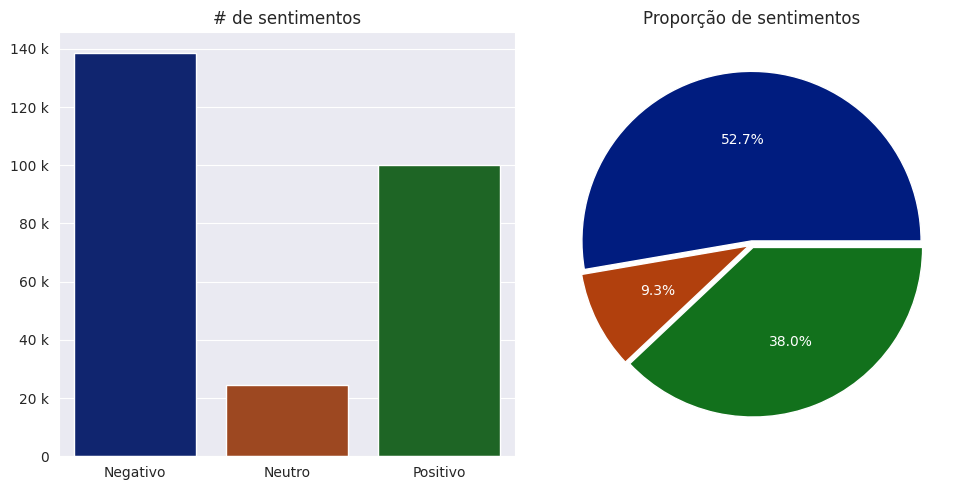

In [20]:
# Define the formatter function
def thousands_formatter(x, pos):
    if x == 0:
        return "0"
    return "%1.0f k" % (x * 1e-3)


gb = df.value_counts("label").sort_index()
gb.index = gb.index.map({0: "Negativo", 1: "Neutro", 2: "Positivo"})

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig: Figure
axs: list[Axes]

palette_color = sns.color_palette("dark")
sns.barplot(x=gb.index, y=gb, ax=axs[0], hue=gb.index, palette=palette_color)
gb.plot.pie(
    ax=axs[1],
    autopct="%1.1f%%",
    explode=[0.02, 0.02, 0.02],
    colors=palette_color,
    textprops={"color": "white"},
)
# Apply the formatter to the y-axis
axs[0].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
titles = ["# de sentimentos", "Proporção de sentimentos"]
for ax, title in zip(axs, titles):
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(title)

fig.set_tight_layout(True)

### 3. **Tokenização**

Após termos feito uma avaliação e limpeza preliminar dos dados iniciaremos os passos de Feature Engineering, ou seja, a preparação dos dados para treinamento pelo modelo.

A primeira etapa do processo de Feature Engineering de NLP é a **tokenização**, que consiste em dividir o texto em palavras ou frases menores, chamadas de tokens.


Exemplo:


In [21]:
text = "O rato roeu a roupa do rei de Roma."
tokens = word_tokenize(text)
print(tokens)

['O', 'rato', 'roeu', 'a', 'roupa', 'do', 'rei', 'de', 'Roma', '.']


Esse processo é muitas vezes similar ao processo "split" de strings, mas com algumas diferenças importantes, pois dependendo do método de tokenização utilizado, a divisão pode ser feita de maneira mais inteligente, levando em consideração a estrutura da linguagem, resultando em tokens como "não" e "gostei" ao invés de "não gostei" ou vice-versa.

Aplicando o processo de tokenização em todos os textos do dataset

In [22]:
# aplica a tokenização em todos os textos, ~ 1 min
df["tokens"] = df.text.apply(word_tokenize)

### 4. Limpeza de Dados

Tendo os textos tokenizados, o próximo passo é a limpeza dos dados, que consiste em remover palavras que não são relevantes para a análise como:
- lowercasing: transformar todas as palavras em minúsculas.
- stopwords: palavras comuns que não possuem significado próprio, como "e", "ou", "de", etc.
- pontuações: sinais de pontuação como ".", ",", "!", etc.
- caracteres especiais: emojis, símbolos, etc.
- lematização: reduzir palavras flexionadas ao seu lema ou raiz, como "correr" para "corre" e "bonzinho" para "bom".


**Atenção**
Muita atenção para o fato de que esse processo de limpeza deve considerar o contexto do problema, pois em alguns casos algumas dessas etapas podem não ser relevantes ou até mesmo prejudiciais para a análise.

Exemplos para a análise de sentimentos:
- lowercasing: uma sentença completamente em maiúsculas pode ser um indicativo de que a pessoa está gritando, e portanto, a remoção de todas as letras maiúsculas pode prejudicar a análise.
- pontuações: a presença de sinais de pontuação pode ser um indicativo de sentimentos fortes, como múltiplas exclamações ou interrogações.
- caracteres especiais: emojis são uma forma comum de expressar sentimentos em textos, e a remoção deles pode prejudicar a análise.
- lematização: em alguns casos pode remover informações importantes, como "melhorzinho" vs "melhor", em que "melhorzinho" pode indicar uma ironia ou um sentimento menos positivo do que "melhor".


Aqui neste notebook iremos aplicar todas essas etapas de limpeza, mas é importante que você avalie o impacto de cada uma delas no seu problema específico.
Ao final, analisaremos o resultado e caso ele não seja satisfatório, podemos voltar e ajustar os parâmetros de limpeza.

##### 4.1 Lowercasing


In [23]:
def lower_case(tokens: list[str]) -> list[str]:
    return [token.lower() for token in tokens]

##### 4.2 Remoção de Pontuações e Caracteres Especiais

In [24]:
def remove_punctuation_and_special_characters(tokens: list[str]) -> list[str]:
    """
    Remove pontuações e caracteres especiais de uma lista de tokens.
    Exemplo:
        Entrada: ["Olá!", "mundo,", "como", "você", "está?😊"]
        Saída: ["Olá", "mundo", "como", "você", "está"]

    """

    return [token for token in tokens if token.isalnum()]

##### 4.3 Remoção de stopwords

In [25]:
# exemplo de stopwords
print(nltk.corpus.stopwords.words("portuguese")[0:10])

['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as']


In [26]:
# aqui utilizaremos uma lista de referência de stopwords em português
stopwords = set(nltk.corpus.stopwords.words("portuguese"))


def remove_stopwords(tokens: list[str]) -> list[str]:
    """
    Remove as stopwords de uma lista de tokens.
    Exemplo: ['eu', 'não', 'sei'] -> ['sei']
    """

    return [token for token in tokens if token not in stopwords]

In [27]:
stopwords.remove("não")

In [28]:
remove_stopwords(["eu", "não", "sei"])

['não', 'sei']

##### 4.4 Lematização


In [29]:
lemmatizer = nltk.stem.RSLPStemmer()


def lematize(tokens: list[str]) -> list[str]:
    """
    Lematiza os tokens de uma lista de palavras.
    Utiliza o stemmer RSLPStemmer do nltk, que é um stemmer para a língua portuguesa.
    """
    return [lemmatizer.stem(token) for token in tokens]

##### 4.5 Aplicando todos os passos de limpeza nos textos tokenizados

In [30]:
def final_cleanup(tokens: list[str]) -> list[str]:
    """
    Remove sentenças e tokens vazios.
    """
    sentence_tokens = [token for token in tokens if token]
    return sentence_tokens if sentence_tokens else None

In [31]:
def cleaning_pipeline(tokens: list[str]) -> list[str]:
    tokens = lower_case(tokens)
    tokens = remove_punctuation_and_special_characters(tokens)
    tokens = remove_stopwords(tokens)
    tokens = lematize(tokens)
    tokens = final_cleanup(tokens)
    return tokens

In [32]:
# ~ 1.5 min
df["cleaned_tokens"] = df.tokens.apply(cleaning_pipeline)
df.drop(columns=["tokens"], inplace=True)

In [33]:
df = df[df.cleaned_tokens.notnull()]
df.head()

,text,label,cleaned_tokens
0,"Mais uma vez, o Sr. Costner arrumou um filme p...",0,"[vez, costn, arrum, film, temp, necess, além, ..."
1,Este é um exemplo do motivo pelo qual a maiori...,0,"[exempl, motiv, maior, film, açã, mesm, genér,..."
2,"Primeiro de tudo eu odeio esses raps imbecis, ...",0,"[prim, tud, odei, rap, imbecil, não, pod, agir..."
3,Nem mesmo os Beatles puderam escrever músicas ...,0,"[beatl, pud, escrev, músic, tod, gost, emb, wa..."
4,Filmes de fotos de latão não é uma palavra apr...,0,"[film, fot, lat, não, palavr, apropri, verdad,..."


##### 4.6 Avaliando o dataset limpo e processado

Palavras mais frequentes por classe

In [34]:
# Distribuição de caracteres por classe
counter_neg = Counter()
counter_neutral = Counter()
counter_pos = Counter()

df[df.label == 0].cleaned_tokens.apply(counter_neg.update)
df[df.label == 1].cleaned_tokens.apply(counter_neutral.update)
df[df.label == 2].cleaned_tokens.apply(counter_pos.update)

n = 20
counter_df = pd.DataFrame(
    counter_neg.most_common(n)
    + counter_neutral.most_common(n)
    + counter_pos.most_common(n),
    columns=["token", "count"],
)
counter_df["label"] = [0] * n + [1] * n + [2] * n
counter_df.head()

,token,count,label
0,film,100224,0
1,não,87181,0
2,sent,59403,0
3,sint,51158,0
4,nao,32949,0


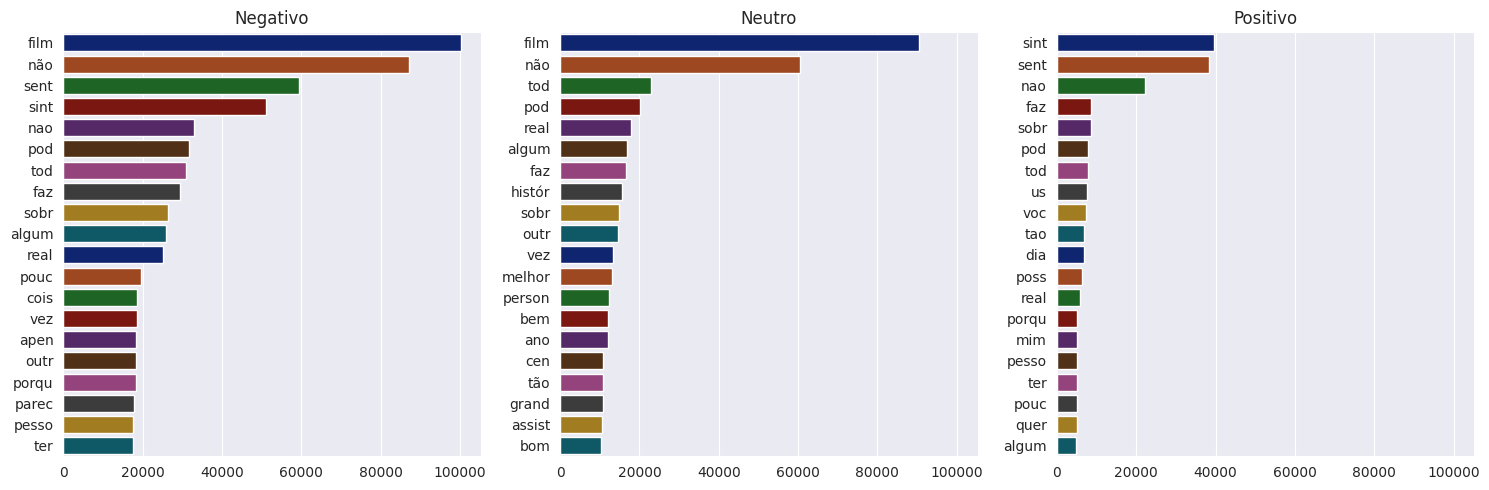

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
fig: Figure
axs: list[Axes]

for i, ax in enumerate(axs):
    sns.barplot(
        x="count",
        y="token",
        data=counter_df[counter_df.label == i],
        ax=ax,
        palette=palette_color,
    )
    ax.set_title(["Negativo", "Neutro", "Positivo"][i])
    ax.set_ylabel("")
    ax.set_xlabel("")

fig.set_tight_layout(True)

Frequência de caracteres por classe

In [36]:
counter_neg = Counter()
counter_neutral = Counter()
counter_pos = Counter()


df[df.label == 0].cleaned_tokens.apply(lambda x: counter_neg.update("".join(x)))
df[df.label == 1].cleaned_tokens.apply(lambda x: counter_neutral.update("".join(x)))
df[df.label == 2].cleaned_tokens.apply(lambda x: counter_pos.update("".join(x)))

n = 30
counter_df = pd.DataFrame(
    counter_neg.most_common(n)
    + counter_neutral.most_common(n)
    + counter_pos.most_common(n),
    columns=["char", "%"],
)
counter_df["label"] = [0] * n + [1] * n + [2] * n

counter_df["%"] = (
    counter_df.set_index("label")["%"] / counter_df.groupby(["label"]).sum()["%"]
).reset_index(drop=True)

counter_df.head()

,char,%,label
0,e,0.093301,0
1,a,0.080990,0
2,r,0.077830,0
3,i,0.076986,0
4,n,0.072517,0


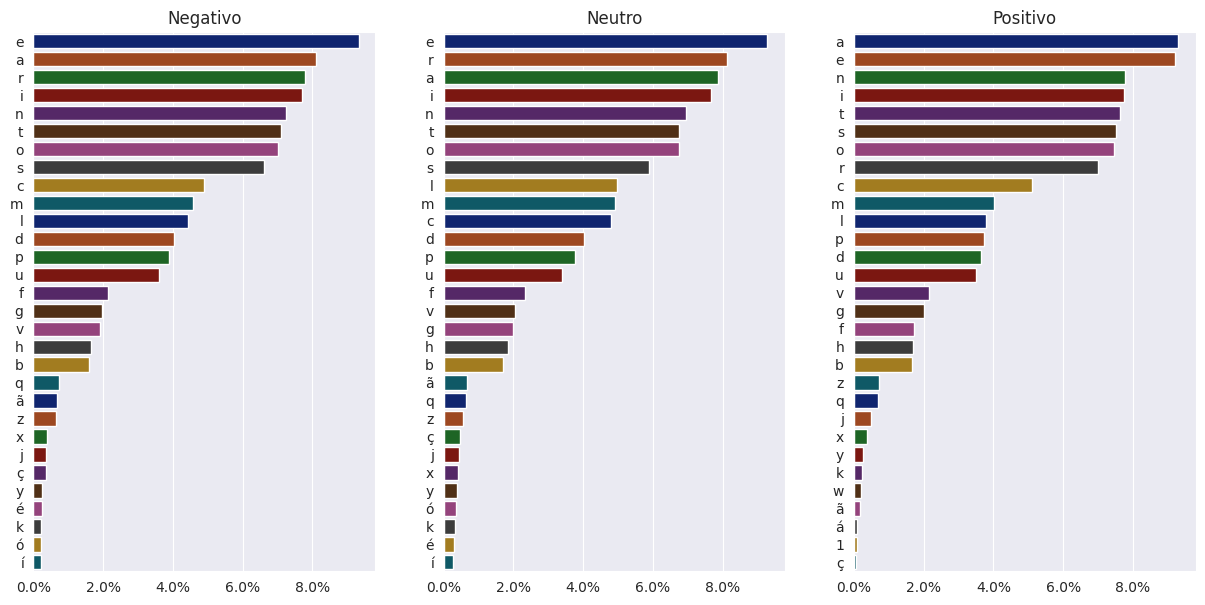

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(15, 7), sharex=True)
fig: Figure
axs: list[Axes]

for i, ax in enumerate(axs):
    sns.barplot(
        x="%",
        y="char",
        data=counter_df[counter_df.label == i],
        ax=ax,
        palette=palette_color,
    )
    ax.set_title(["Negativo", "Neutro", "Positivo"][i])
    ax.set_ylabel("")
    ax.set_xlabel("")
    # Assuming 'ax' is your axis object
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

### 5. Modelando o problema

Neste momento, os textos estão limpos e prontos para serem transformados para as diferentes representações numéricas necessária para treinarmos os modelos.

Iremos portanto criar uma representação chamada de Bag of Words, que consiste em contar a frequência de cada palavra em cada texto, criando uma matriz em que cada linha representa um texto e cada coluna representa uma palavra.

Na sequência, iremos treinar modelos de classificação para prever a classe (sentimento) de cada texto.

##### 5.1 **Bag of Words (BoW)**:


No context de sentiment analysis, a representação mais comum é a Bag of Words (BoW), que consiste em contar a frequência de cada palavra em cada texto, criando uma matriz de ocorrência de palavras, que posteriormente será utilizada para treinar um modelo de classificação.

In [38]:
individual_counter = df.cleaned_tokens.apply(Counter)
individual_counter.head()

0    {'vez': 1, 'costn': 3, 'arrum': 1, 'film': 1, ...
1    {'exempl': 1, 'motiv': 1, 'maior': 1, 'film': ...
2    {'prim': 1, 'tud': 2, 'odei': 1, 'rap': 1, 'im...
3    {'beatl': 1, 'pud': 1, 'escrev': 1, 'músic': 2...
4    {'film': 2, 'fot': 2, 'lat': 1, 'não': 2, 'pal...
Name: cleaned_tokens, dtype: object

In [39]:
individual_counter.iloc[0]

Counter({'não': 4,
         'costn': 3,
         'import': 3,
         'person': 3,
         'kutch': 3,
         'além': 2,
         'nenhum': 2,
         'fantasm': 2,
         'armári': 2,
         'melhor': 2,
         'vez': 1,
         'arrum': 1,
         'film': 1,
         'temp': 1,
         'necess': 1,
         'terr': 1,
         'seqü': 1,
         'resgat': 1,
         'mar': 1,
         'qual': 1,
         'pouc': 1,
         'simples': 1,
         'maior': 1,
         'cost': 1,
         'realiz': 1,
         'log': 1,
         'iníci': 1,
         'esquec': 1,
         'tard': 1,
         'dev': 1,
         'arrog': 1,
         'superconfi': 1,
         'ashton': 1,
         'problem': 1,
         'sai': 1,
         'garot': 1,
         'pens': 1,
         'qualqu': 1,
         'outr': 1,
         'pesso': 1,
         'redor': 1,
         'mostr': 1,
         'sinal': 1,
         'desorden': 1,
         'únic': 1,
         'obstácul': 1,
         'parec': 1,
         

In [40]:
# dividindo o dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    individual_counter, df.label, random_state=42, shuffle=True, stratify=df.label
)

vocabulary = set.union(*X_train.apply(lambda x: set(x.keys())))

# Transforming the Counter objects into feature matrices using DictVectorizer
vectorizer = DictVectorizer(sparse=True)
X_train_matrix = vectorizer.fit_transform(X_train)
X_test_matrix = vectorizer.transform(X_test)

# posteirormente, removeremos as palavras que aparecem apenas nos dados de teste

Modelo de Classificação Naive Bayes

In [41]:
def plot_confusion_matrix(true_labels, predictions):
    """
    Plots a confusion matrix using Seaborn's heatmap.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig: Figure
    ax: Axes
    cm = 100 * confusion_matrix(true_labels, predictions, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"format": "%.0f%%"})

    # Custom function to format the annotations as percentages
    for text in ax.texts:
        text.set_text(f"{float(text.get_text()):.1f}%")

    ax.set_xlabel("Predicted labels")
    ax.set_ylabel("True labels")
    ax.set_title("Confusion Matrix")
    ax.xaxis.set_tick_params(rotation=0)
    ax.yaxis.set_tick_params(rotation=0)
    fig.set_tight_layout(True)
    plt.show()

In [42]:
classifier = MultinomialNB().fit(X_train_matrix, y_train)

In [43]:
predictions = classifier.predict(X_test_matrix)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.41      0.55     34685
           1       0.69      0.92      0.79      6144
           2       0.56      0.91      0.69     24988

    accuracy                           0.65     65817
   macro avg       0.70      0.75      0.68     65817
weighted avg       0.72      0.65      0.63     65817



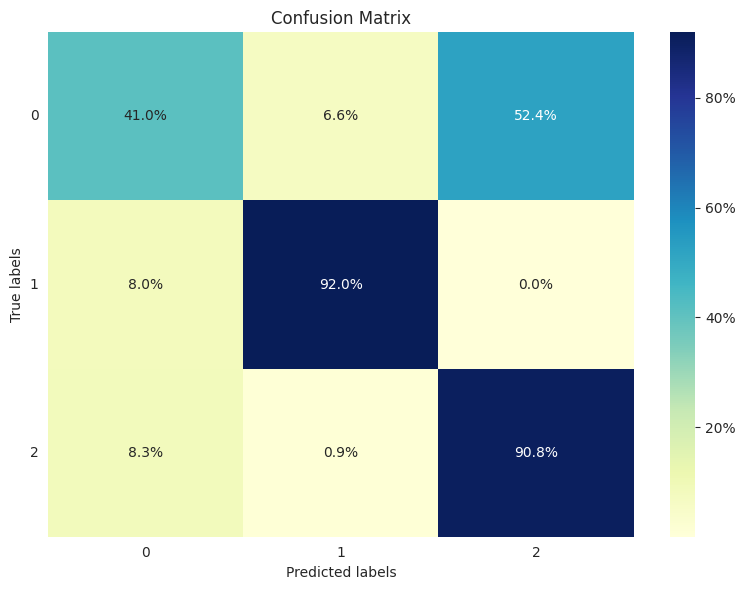

In [44]:
plot_confusion_matrix(y_test, predictions)

In [45]:
df_diff = pd.DataFrame(
    {
        "true": y_test,
        "pred": predictions,
        "text": df.loc[y_test.index, "text"],
        "tokens": df.loc[y_test.index, "cleaned_tokens"],
    }
)

for row in df_diff[(df_diff.true != df_diff.pred) & (predictions == 2)].head().iterrows():
    print(row[1].text)
    print(row[1].tokens)
    print()

eu tentei passar mas e impossivel totalmente fechada fora todos os meus sentimentos as emocoes de serem reprimidos ao inves do que expressa e parte do problema ele tambem nao pode ser a solucao
['tent', 'pass', 'impossi', 'total', 'fech', 'tod', 'sent', 'emoco', 'ser', 'reprim', 'inv', 'express', 'part', 'problem', 'tamb', 'nao', 'pod', 'soluca']

eu acho que e inevitavel que voce vai cansar de ele se sentir como voce se tornar cansado e visto muito
['ach', 'inevita', 'voc', 'vai', 'cans', 'sent', 'voc', 'torn', 'cans', 'vist']

eu comprei quando me tornei vegetariano entao eu sinto uma especie de sentimental sobre isso
['compr', 'torn', 'vegetari', 'enta', 'sint', 'especi', 'sentiment', 'sobr']

eu sinto como se eu tivesse irritado voce princesa eleanor
['sint', 'irrit', 'voc', 'princes', 'elean']

"Este jogo tem valor de fantasia eu odeio os Cowboys mas preciso que eles façam grandes coisas. Romo Austin e Dallas vamos lá!"
['jog', 'val', 'fantas', 'odei', 'cowboy', 'precis', 'faç', '

In [46]:
diff_counter = Counter()
df_diff[(df_diff.true != df_diff.pred) & (predictions == 2)].tokens.apply(
    diff_counter.update
)
diff_counter.most_common(10)

[('sent', 8982),
 ('sint', 8609),
 ('nao', 6845),
 ('tao', 2186),
 ('sobr', 2181),
 ('voc', 1880),
 ('faz', 1778),
 ('pouc', 1760),
 ('porqu', 1629),
 ('tod', 1440)]

##### 5.2 Utilizando a técnica TF-IDF

TF-IDF é uma técnica de representação de texto que leva em consideração a frequência de uma palavra em um texto e a frequência da palavra em todo o corpus, atribuindo um peso maior para palavras que são mais raras no corpus e um peso menor para palavras que são mais comuns.

O objetivo é identificar palavras que são mais relevantes para a classificação do texto, uma vez que palavras muito comuns como "e", "ou", "de", etc. não são muito informativas para a classificação.

Para essa técnica, não utilizaremos o vertor de tokens, mas sim o texto limpo.

In [47]:
X_train_text, X_test_text, y_train_text, y_test_text = (
    df.text.loc[X_train.index],
    df.text.loc[X_test.index],
    df.label.loc[X_train.index],
    df.label.loc[X_test.index],
)

              precision    recall  f1-score   support

           0       0.73      0.92      0.81     34685
           1       0.86      0.47      0.61      6144
           2       0.88      0.65      0.75     24988

    accuracy                           0.78     65817
   macro avg       0.82      0.68      0.72     65817
weighted avg       0.80      0.78      0.77     65817



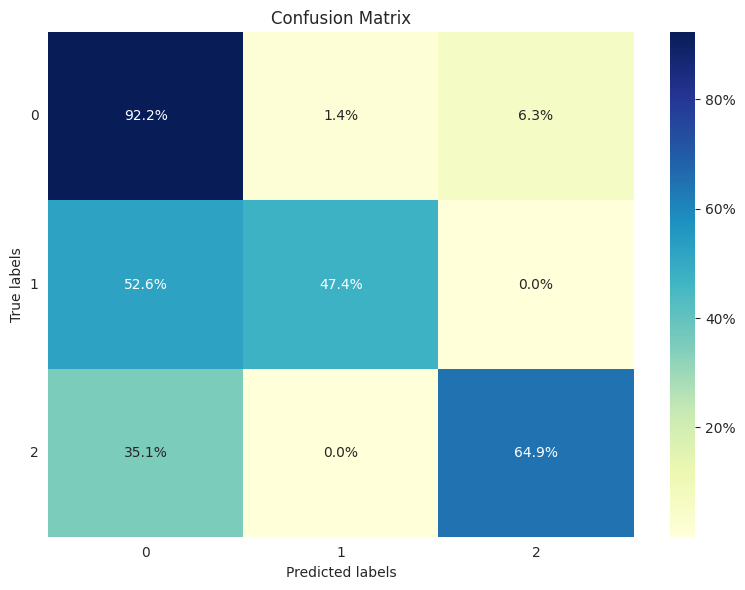

In [48]:
# Create TF-IDF feature matrix
tf_idf_vectorizer = TfidfVectorizer()
X_train_text = tf_idf_vectorizer.fit_transform(X_train_text)
X_test_text = tf_idf_vectorizer.transform(X_test_text)

# Train the Naive Bayes classifier with TF-IDF features
classifier = MultinomialNB().fit(X_train_text, y_train)
predictions = classifier.predict(X_test_text)
print(classification_report(y_test, predictions))
plot_confusion_matrix(y_test, predictions)

In [49]:
non_1_train, non_1_test = y_train!=1, y_test != 1

X_train_text, X_test_text, y_train_text, y_test_text = (
    df.text.loc[(X_train.index)][y_train != 1],
    df.text.loc[(X_test.index)][y_test != 1],
    df.label.loc[(X_train.index)][y_train != 1],
    df.label.loc[(X_test.index)][y_test != 1],
)

              precision    recall  f1-score   support

           0       0.80      0.93      0.86     34685
           2       0.87      0.68      0.77     24988

    accuracy                           0.83     59673
   macro avg       0.84      0.81      0.81     59673
weighted avg       0.83      0.83      0.82     59673



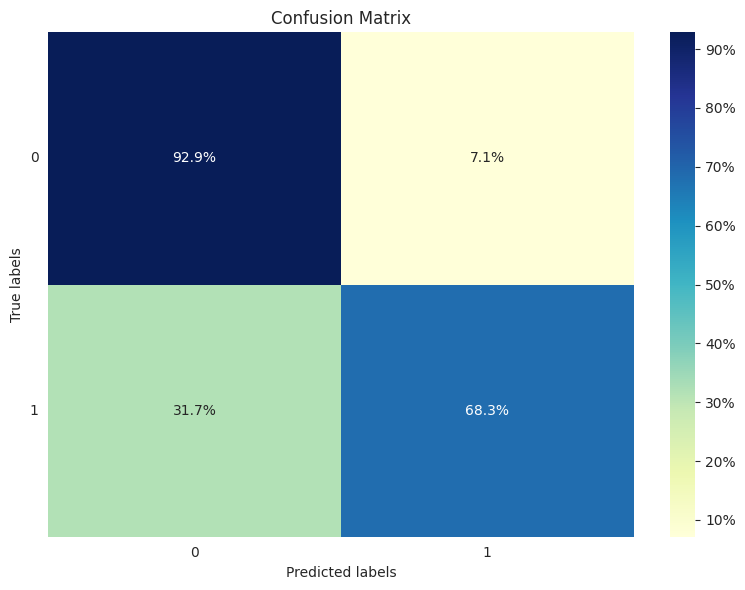

In [50]:
# # Create TF-IDF feature matrix
tf_idf_vectorizer = TfidfVectorizer()
X_train_text = tf_idf_vectorizer.fit_transform(X_train_text)
X_test_text = tf_idf_vectorizer.transform(X_test_text)

# Train the Naive Bayes classifier with TF-IDF features
classifier = MultinomialNB().fit(X_train_text, y_train[y_train!=1])
predictions = classifier.predict(X_test_text)
print(classification_report(y_test[y_test!=1], predictions))
plot_confusion_matrix(y_test[y_test != 1], predictions)

##### Testando um modelo de XGBoost para as duas representações

Testando para BoW

In [51]:
# ~ 3 min
bow_model = XGBClassifier().fit(X_train_matrix, y_train)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84     34685
           1       0.84      0.82      0.83      6144
           2       0.83      0.77      0.80     24988

    accuracy                           0.82     65817
   macro avg       0.83      0.82      0.82     65817
weighted avg       0.82      0.82      0.82     65817



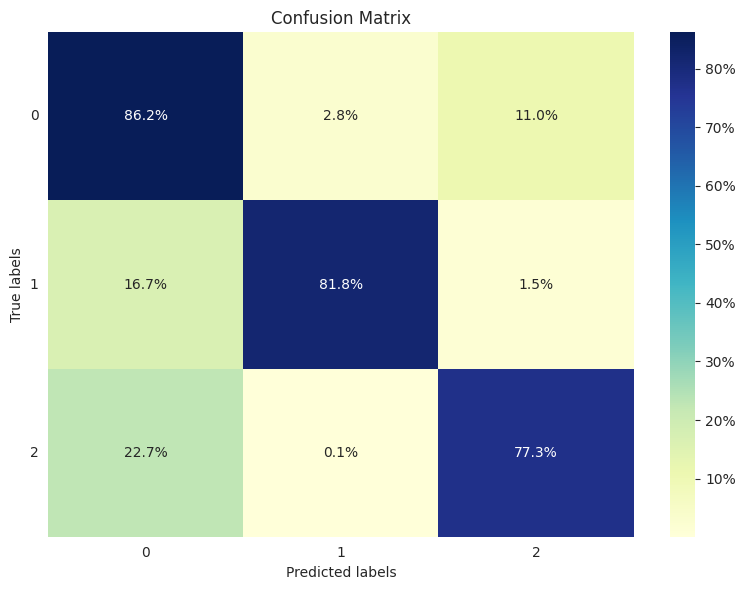

In [52]:
# Avaliando o melhor modelo no conjunto de testes
y_pred = bow_model.predict(X_test_matrix)
print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

Testando para TF-IDF

In [53]:
# ~ 3 min
# ajustando os rótulos para 0 e 1 apenas, removendo a classe neutra
y_train_text_adjusted = y_train_text.apply(lambda x: {0: 0, 2: 1}[x])
y_test_text_adjusted = y_test_text.apply(lambda x: {0: 0, 2: 1}[x])
tf_idf_models = XGBClassifier().fit(X_train_text, y_train_text_adjusted)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86     34685
           1       0.83      0.74      0.78     24988

    accuracy                           0.83     59673
   macro avg       0.83      0.81      0.82     59673
weighted avg       0.83      0.83      0.82     59673



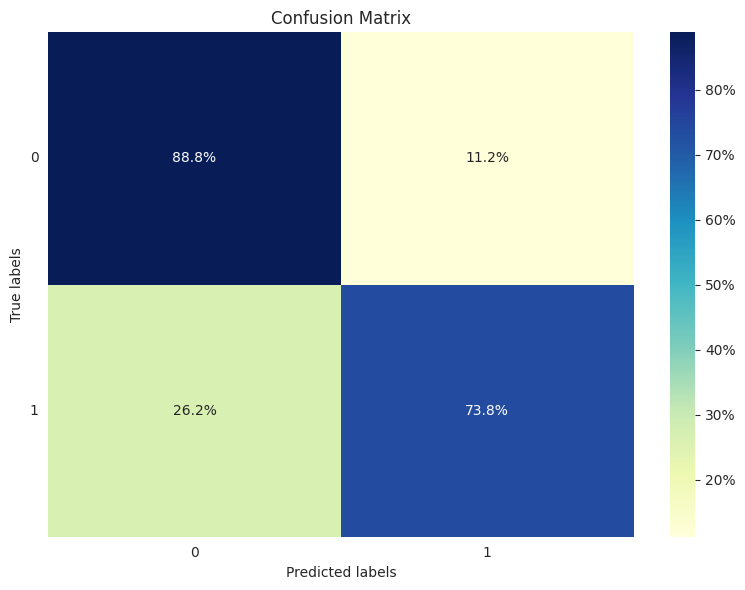

In [54]:
# Avaliando o melhor modelo no conjunto de testes

y_pred = tf_idf_models.predict(X_test_text)
print(classification_report(y_test_text_adjusted, y_pred))
plot_confusion_matrix(y_test_text_adjusted, y_pred)